In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans



In [2]:
df = pd.read_csv('LargeMovieDataset.csv')
df.head()

,MovieID,Title,Genre,Rating,Popularity
0,1,Chaos Theory 1,Horror,3.5,93
1,2,Mystic Falls 2,Sci-Fi,3.4,34
2,3,The Legend 3,Horror,4.2,74
3,4,Chaos Theory 4,Documentary,2.2,59
4,5,Infinite Horizon 5,Sci-Fi,3.7,77


In [3]:
df['Title'].unique().shape

(10000,)

In [4]:
df['Genre'].unique().shape

(10,)

In [5]:
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df['Genre'].values.reshape(-1, 1))


one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Genre']))

df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded = df_encoded.drop('Genre', axis=1)
df_encoded

,MovieID,Title,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,1,Chaos Theory 1,3.5,93,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,Mystic Falls 2,3.4,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,The Legend 3,4.2,74,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,Chaos Theory 4,2.2,59,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Infinite Horizon 5,3.7,77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Mystic Falls 9996,4.7,30,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9996,9997,Chaos Theory 9997,4.3,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9997,9998,Storm Riders 9998,3.7,77,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9998,9999,Fearless Fighter 9999,4.2,34,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
from sklearn.preprocessing import StandardScaler

df_encoded.drop('Title', axis=1, inplace=True)
df_encoded.drop('MovieID', axis=1, inplace=True)
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)
scaled_df.head()

,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,0.430247,1.476176,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025
1,0.343143,-0.584230,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025
2,1.039970,0.812655,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025
3,-0.702096,0.288823,-0.329244,-0.334628,-0.327188,2.986743,-0.327001,-0.337576,-0.342882,-0.333518,-0.329244,-0.337025
4,0.604453,0.917422,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025


In [7]:
wcss = []
for i in range(1, 20):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)  # Drop non-numeric columns if any
    wcss.append(kmeans.inertia_)

wcss

[119999.99999999999,
 112459.05718317149,
 97763.12858276554,
 86645.5002889821,
 75557.56218689555,
 64381.49909232779,
 53308.46685063388,
 42273.60749873868,
 31132.789611881108,
 19983.908391903544,
 19203.817282518055,
 18409.397843352257,
 17977.977099813877,
 17199.051913377712,
 16441.515270902746,
 15677.82205237385,
 15214.909662796857,
 14451.5343442479,
 13786.694625200284]

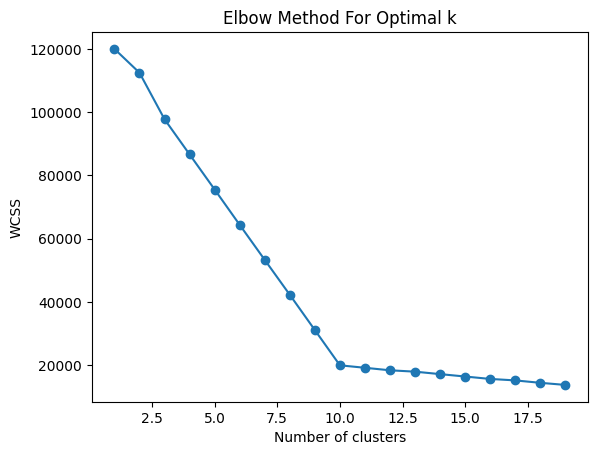

In [8]:
plt.plot(range(1, 20), wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
def recommend_movies(movie_title, df, scaled_df, kmeans, num_recommendations=5):
    movie_index = df[df['Title'] == movie_title].index[0]
    print(movie_index)
    
    movie_cluster_label = kmeans.labels_[movie_index]
    
    similar_movies_indices = [index for index, label in enumerate(kmeans.labels_) if label == movie_cluster_label]
    
    similar_movies_indices.remove(movie_index)
    
    recommended_movies = df.iloc[similar_movies_indices]['Title'].head(num_recommendations).tolist()
    
    return recommended_movies


movie_title = 'Final Stand 12'  
recommendations = recommend_movies(movie_title, df, scaled_df, kmeans)

print(f"Movies similar to '{movie_title}':")

for movie in recommendations:
    print(movie)

11
Movies similar to 'Final Stand 12':
Chaos Theory 1
The Legend 3
Dream Catcher 16
Hidden Truth 59
City Lights 60


In [10]:
def recommend_movies_for_multiple_titles(movie_titles, df, scaled_df, kmeans, num_recommendations=5):
    recommendations_dict = {}
    
    for movie_title in movie_titles:
        movie_index = df[df['Title'] == movie_title].index[0]
        movie_cluster_label = kmeans.labels_[movie_index]
        similar_movies_indices = [index for index, label in enumerate(kmeans.labels_) if label == movie_cluster_label]
        similar_movies_indices.remove(movie_index)
        recommended_movies = df.iloc[similar_movies_indices]['Title'].head(num_recommendations).tolist()
        recommendations_dict[movie_title] = recommended_movies
    
    return recommendations_dict

movie_titles = ['Final Stand 12', 'Chaos Theory 1']
recommendations = recommend_movies_for_multiple_titles(movie_titles, df, scaled_df, kmeans)

for movie_title, recommended_movies in recommendations.items():
    print(f"Movies similar to '{movie_title}':")
    for movie in recommended_movies:
        print(movie)
    print()

Movies similar to 'Final Stand 12':
Chaos Theory 1
The Legend 3
Dream Catcher 16
Hidden Truth 59
City Lights 60

Movies similar to 'Chaos Theory 1':
The Legend 3
Final Stand 12
Dream Catcher 16
Hidden Truth 59
City Lights 60



In [11]:
import pickle

# Save the KMeans model and the scaled dataframe to a pickle file
with open('movie_recommendation_model.pkl', 'wb') as file:
    pickle.dump((kmeans, scaled_df, df), file)